# Sparse Variate Selection — Analysis

Analyses the sparsemax selection weights and cross-attention from the forecasting model on the held-out test set.

**Key quantities computed per variate $j$:**
- **Support frequency** $s_j = \frac{1}{T}\sum_t \mathbf{1}(\alpha_{t,j}>\varepsilon)$: fraction of test windows where the variate receives non-zero weight.
- **Mean weight** $\bar\alpha_j = \frac{1}{T}\sum_t \alpha_{t,j}$: average sparsemax allocation.
- **Conditional mean** $\bar\alpha_j^+ = \mathbb{E}[\alpha_{t,j}\mid \alpha_{t,j}>\varepsilon]$: mean weight *given* selection, separating frequent-small from rare-large contributors.
- **Active variate count** $K_t = \sum_j \mathbf{1}(\alpha_{t,j}>\varepsilon)$: sparsity of each selection event.

**Figures produced:**
1. Sorted bar chart — support frequency and mean weight (main display)
2. Cross-attention profile — mean attention by variate and horizon
3. Binary selection raster — when the selected set changes over test windows
4. Distribution of active variate count $K_t$
5. Summary statistics table
6. Joint selection × attention heatmap (supplementary)

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import warnings
import json

warnings.filterwarnings('ignore')

In [46]:
# ── Publication style ──────────────────────────────────────────────────────────
FONT_FAMILY   = 'DejaVu Sans'
BASE_SIZE     = 9
TITLE_SIZE    = 10
LABEL_SIZE    = 9
TICK_SIZE     = 8
ANNOT_SIZE    = 7.5
FIG_DPI       = 150
SAVE_DPI      = 300

# Palette
C_FREQ   = '#2166AC'
C_WEIGHT = 'crimson'
C_COND   = '#4DAC26'
C_ATTN   = 'Blues'
C_SEL    = mcolors.ListedColormap(['#00000000', "#2141AC"])
C_JOINT  = 'YlOrRd'

plt.rcParams.update({
    'font.family'      : FONT_FAMILY,
    'font.size'        : BASE_SIZE,
    'axes.titlesize'   : TITLE_SIZE,
    'axes.labelsize'   : LABEL_SIZE,
    'xtick.labelsize'  : TICK_SIZE,
    'ytick.labelsize'  : TICK_SIZE,
    'axes.linewidth'   : 0.6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'       : FIG_DPI,
    'savefig.dpi'      : SAVE_DPI,
    'savefig.bbox'     : 'tight',
    'legend.fontsize'  : ANNOT_SIZE,
    'legend.frameon'   : False,
})

In [33]:
# ── Load data ─────────────────────────────────────────────────────────────────
NPZPATH = 'model_logs/final_retrain_run/preds_test_set.compact.npz'
raw = np.load(NPZPATH, allow_pickle=True)
meta = json.loads(raw['__metadata__'].item())

def _load_node(node, raw):
    t = node['type']
    if t == 'ndarray':
        return raw[node['name']]
    elif t == 'scalar':
        return node['value']
    elif t == 'list':
        return [_load_node(item, raw) for item in node['items']]
    elif t == 'dict':
        return {k['value']: _load_node(v, raw) for k, v in node['items']}
    return node

preds = _load_node(meta['tree'], raw)

covariate_names = preds['covariate_names']        # list[str], length 97
diag            = preds['diagnostics']

# sparsemax weights  α_{t,j}  — shape (T, J)
# selection is computed per origin t and is constant across horizons
alpha      = diag['selection_weights'].astype(np.float64)        # (T, J)

# cross-attention (averaged over layers)  — shape (T, H, J)
cross_attn = diag['cross_attn_mean_layers'].astype(np.float64)   # (T, H, J)

cutoff_us  = preds['cutoff_idx']                  # Unix µs
cutoff_dt  = pd.to_datetime(cutoff_us, unit='us', utc=True)

T, J = alpha.shape
H    = cross_attn.shape[1]
EPS  = 1e-8   # floating-point tolerance for "non-zero"

print(f'Test origins T={T:,}, variates J={J}, horizons H={H}')
print(f'Date range: {cutoff_dt[0].date()} → {cutoff_dt[-1].date()}')

Test origins T=11,391, variates J=97, horizons H=24
Date range: 2025-01-15 → 2026-05-05


In [34]:
# ── Core statistics ────────────────────────────────────────────────────────────
selected = alpha > EPS                       # (T, J) bool mask

# s_j — support frequency
support_freq  = selected.mean(axis=0)        # (J,)

# ᾱ_j — unconditional mean weight
mean_weight   = alpha.mean(axis=0)           # (J,)

# ᾱ_j+ — conditional mean  E[α_j | α_j > ε]
alpha_masked  = np.where(selected, alpha, np.nan)
cond_mean     = np.nanmean(alpha_masked, axis=0)   # (J,), nan if never selected

# K_t — number of active variates per origin
K_t = selected.sum(axis=1)                  # (T,)

ever_sel = (selected.sum(axis=0) > 0).sum()

print(f'Variates ever selected: {ever_sel}/{J}  ({100*ever_sel/J:.1f}%)')
print(f'Global selection rate : {selected.mean():.4f}  ({100*selected.mean():.2f}%)')
print()
print(f'K_t  mean={K_t.mean():.2f}  std={K_t.std():.2f}  '
      f'min={K_t.min()}  median={np.median(K_t):.0f}  max={K_t.max()}')

Variates ever selected: 68/97  (70.1%)
Global selection rate : 0.0530  (5.30%)

K_t  mean=5.15  std=1.77  min=1  median=5  max=14


In [35]:
# ── Summary DataFrame ─────────────────────────────────────────────────────────
stats_df = pd.DataFrame({
    'variate'     : covariate_names,
    'support_freq': support_freq,
    'mean_weight' : mean_weight,
    'cond_mean'   : cond_mean,
    'n_selected'  : selected.sum(axis=0).astype(int),
}).sort_values('support_freq', ascending=False).reset_index(drop=True)
stats_df.index += 1
stats_df.index.name = 'rank'

pd.set_option('display.float_format', '{:.4f}'.format)
print('Top 20 variates by support frequency:')
display(stats_df.head(20))

Top 20 variates by support frequency:


,variate,support_freq,mean_weight,cond_mean,n_selected
rank,,,,,
1,Gegenbauer_0.1_deg3_MA24,0.9956,0.5222,0.5245,11341
2,Gegenbauer_0.1_deg6_vol24,0.7174,0.1780,0.2481,8172
3,liquidation_USD,0.3999,0.0387,0.0969,4555
4,E_high,0.3420,0.0452,0.1321,3896
5,Gegenbauer_0.1_deg3_vol24,0.3308,0.0376,0.1135,3768
6,E_mid,0.2545,0.0273,0.1074,2899
7,tvlUSD_100,0.2484,0.0258,0.1038,2830
8,E_odd_logret,0.2121,0.0152,0.0715,2416
9,tangent_up,0.1947,0.0184,0.0943,2218


In [36]:
# ── Variate display names (shortened for axis labels) ─────────────────────────
RENAME = [
    ('Gegenbauer_0.1_deg', 'Geg'),
    ('_MA24', '_MA24'), ('_logret', '_ret'), ('_vol24', '_v24'),
    ('tvlUSD_', 'tvl_'),
    ('net_amountUSD_', 'netUSD_'), ('net_amount0', 'netAmt0'),
    ('swap_count_', 'swapN_'), ('swap_size_imbalance', 'sz_imb'),
    ('utilisation_rate_', 'util_'), ('supplied_USD_', 'sup_'),
    ('hourlyVolumeUSD', 'volUSD_h'), ('totalValueLockedUSD', 'TVL_aave'),
    ('liquidation_USD', 'liq_USD'),
    ('eth_price_usd', 'ETH'), ('btc_price_usd', 'BTC'),
    ('fear_greed_index', 'fear/greed'),
    ('usd_index', 'DXY'), ('fx_volatility', 'FX_vol'),
    ('curve_entropy', 'crv_H'),
    ('tangent_down', 'tan↓'), ('tangent_up', 'tan↑'),
    ('hhi_24h_rolling_mean', 'HHI_24h'),
    ('tick_width_24h_rolling_median', 'tick_w'),
    ('n_in_range_log_return', 'in_rng_ret'),
    ('weighted_mean_age_hours', 'lp_age'),
    ('gauge_share_3crv', 'gauge_sh'),
]

def shorten(name):
    s = name
    for old, new in RENAME:
        s = s.replace(old, new)
    return s

# Sort variates by support frequency
sort_idx     = np.argsort(support_freq)[::-1]
names_sorted = [covariate_names[i] for i in sort_idx]
short_sorted = [shorten(n) for n in names_sorted]
freq_sorted  = support_freq[sort_idx]
wt_sorted    = mean_weight[sort_idx]
cond_sorted  = cond_mean[sort_idx]

show_mask = freq_sorted > 0.01
n_show    = show_mask.sum()
print(f'Variates with any support: {n_show}/{J}')

Variates with any support: 37/97


## Figure 1 — Variate support frequency and weight

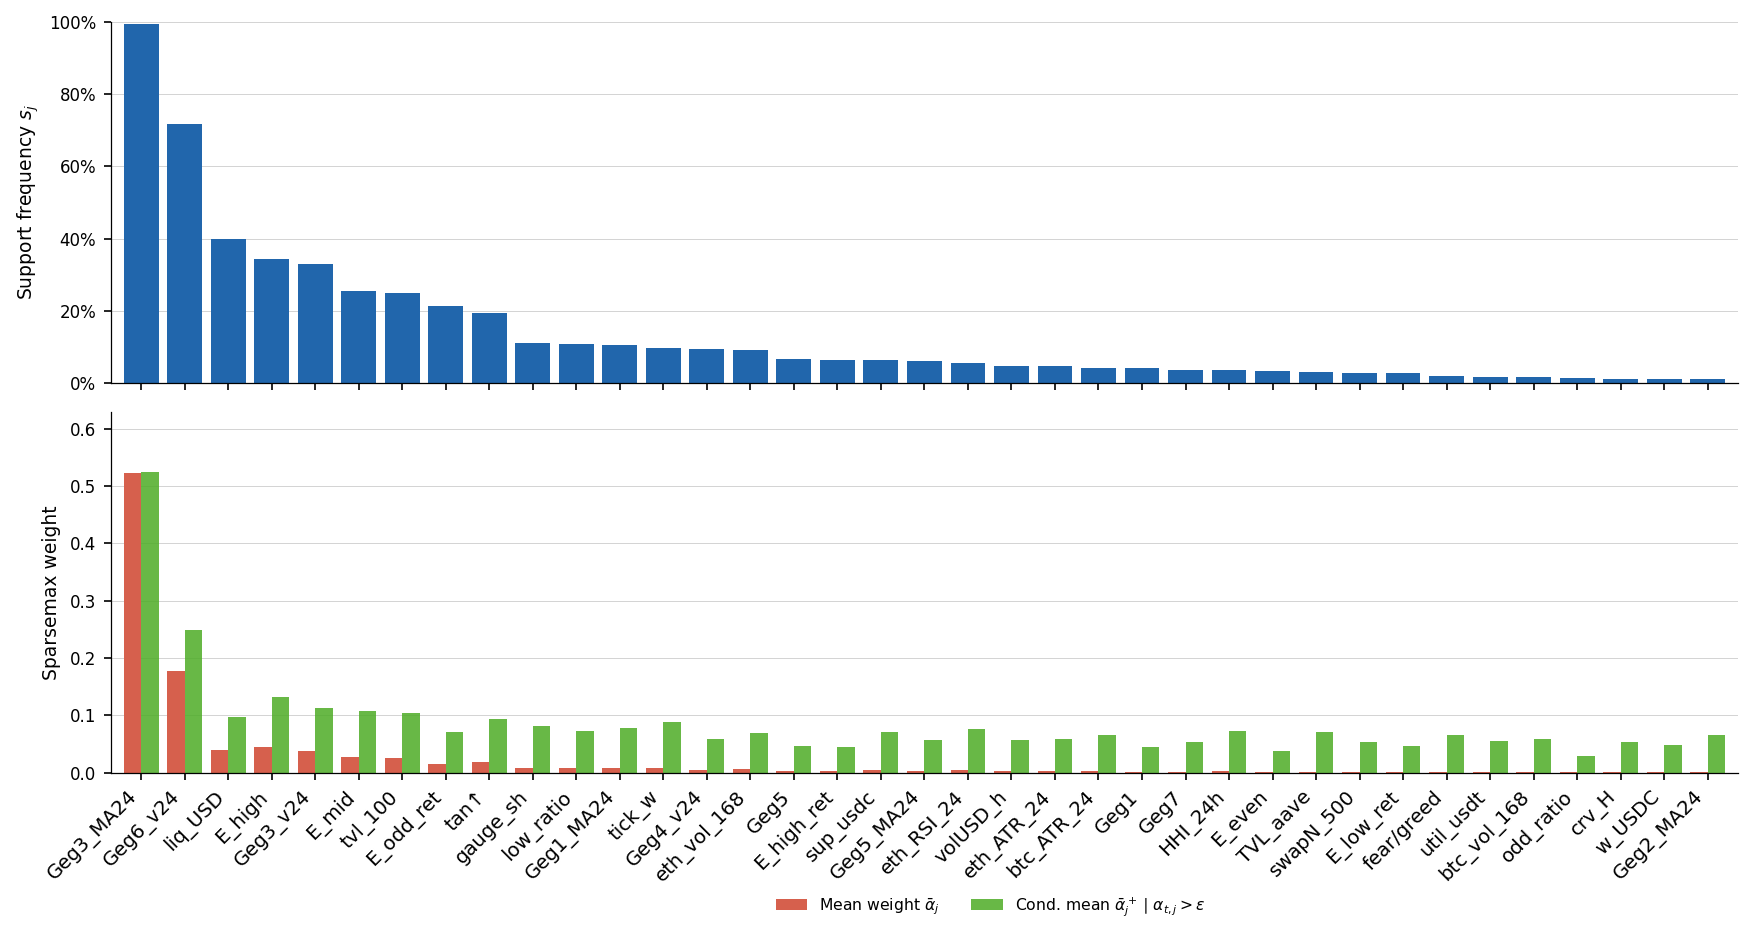

Saved fig1_variate_support_weight.{pdf,png}


In [37]:
ns    = n_show
x     = np.arange(ns)
BAR_W = 0.40

fig, axes = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True,
                         gridspec_kw={'hspace': 0.08})

# Top panel: support frequency
ax0 = axes[0]
ax0.bar(x, freq_sorted[show_mask], width=BAR_W*2, color=C_FREQ,
        linewidth=0, label='Support frequency $s_j$')
ax0.set_ylabel('Support frequency $s_j$')
ax0.set_ylim(0, min(freq_sorted[show_mask].max() * 1.2, 1.0))
ax0.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax0.yaxis.grid(True, lw=0.4, color='#cccccc', zorder=0)
ax0.set_axisbelow(True)

# Bottom panel: mean weight + conditional mean
ax1 = axes[1]
ax1.bar(x - BAR_W/2, wt_sorted[show_mask], width=BAR_W,
        color=C_WEIGHT, linewidth=0, label=r'Mean weight $\bar\alpha_j$')
ax1.bar(x + BAR_W/2, np.nan_to_num(cond_sorted[show_mask]), width=BAR_W,
        color=C_COND, linewidth=0, alpha=0.85,
        label=r'Cond. mean $\bar\alpha_j^+\mid\alpha_{t,j}>\varepsilon$')
ax1.set_ylabel('Sparsemax weight')
ymax = max(wt_sorted[show_mask].max(),
           np.nan_to_num(cond_sorted[show_mask]).max()) * 1.2
ax1.set_ylim(0, ymax)
ax1.legend(loc="upper left", bbox_to_anchor=(0.4, -.3), ncols = 2, frameon = False)
ax1.yaxis.grid(True, lw=0.4, color='#cccccc', zorder=0)
ax1.set_axisbelow(True)

ax1.set_xticks(x)
ax1.set_xticklabels([short_sorted[i] for i in range(ns)],
                    rotation=45, ha='right', fontsize=9.5)
ax1.set_xlim(-0.7, ns - 0.3)

plt.savefig('fig1_variate_support_weight.png', dpi=SAVE_DPI, transparent = True)
plt.show()
print('Saved fig1_variate_support_weight.{pdf,png}')

## Figure 2 — Cross-attention by variate and horizon

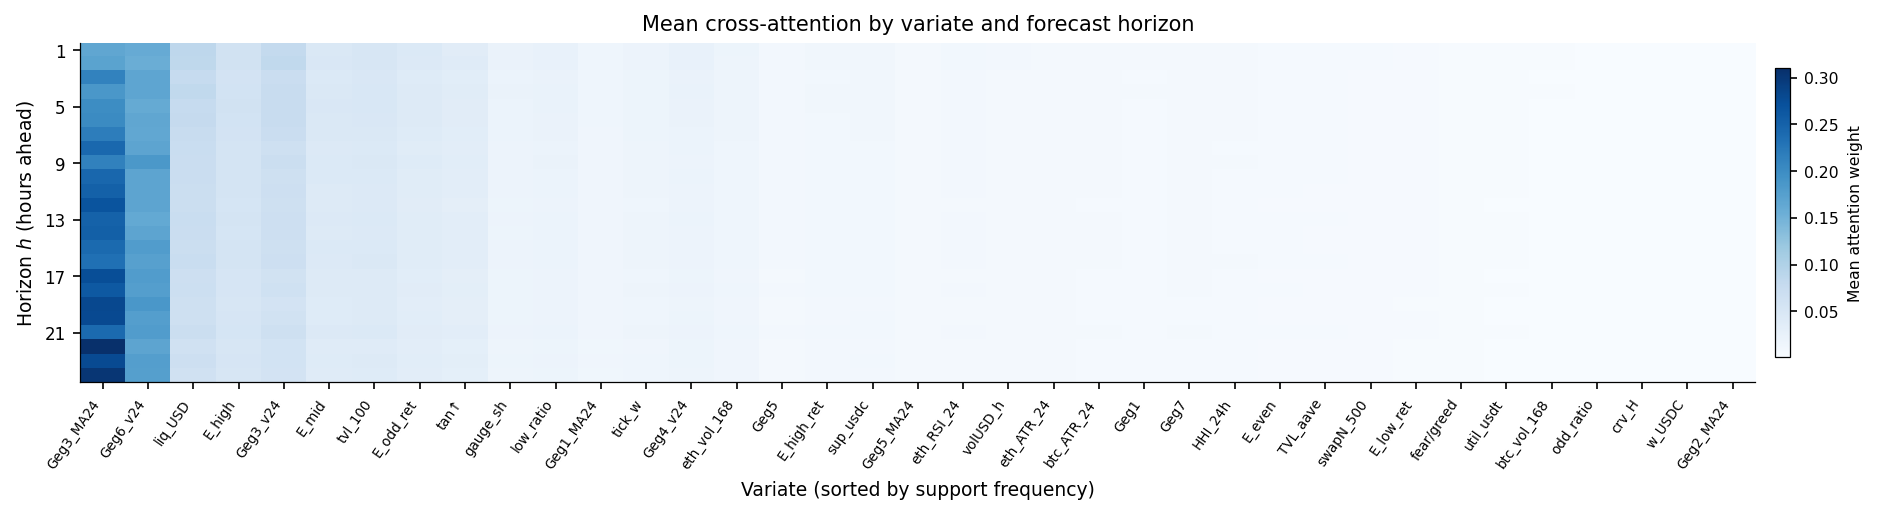

Saved fig2_cross_attention.{pdf,png}


In [38]:
# Mean cross-attention averaged over test origins: (H, J)
mean_cross = cross_attn.mean(axis=0)                             # (H, J)
cross_show = mean_cross[:, sort_idx][:, :n_show]                 # (H, n_show)

fig, ax = plt.subplots(figsize=(14, 3.5))

im = ax.imshow(cross_show, aspect='auto', cmap=C_ATTN,
               origin='upper', interpolation='nearest')

ax.set_xlabel('Variate (sorted by support frequency)')
ax.set_ylabel('Horizon $h$ (hours ahead)')
tick_h = np.arange(0, H, 4)
ax.set_yticks(tick_h)
ax.set_yticklabels(tick_h + 1)
ax.set_xticks(np.arange(n_show))
ax.set_xticklabels([short_sorted[i] for i in range(n_show)],
                   rotation=55, ha='right', fontsize=6.5)
ax.set_title('Mean cross-attention by variate and forecast horizon',
             fontsize=TITLE_SIZE, pad=6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.01)
cb.set_label('Mean attention weight', fontsize=ANNOT_SIZE)
cb.ax.tick_params(labelsize=ANNOT_SIZE)

plt.tight_layout()
plt.savefig('fig2_cross_attention.png', dpi=SAVE_DPI, transparent = True)
plt.show()
print('Saved fig2_cross_attention.{pdf,png}')

## Figure 3 — Binary selection raster over test windows

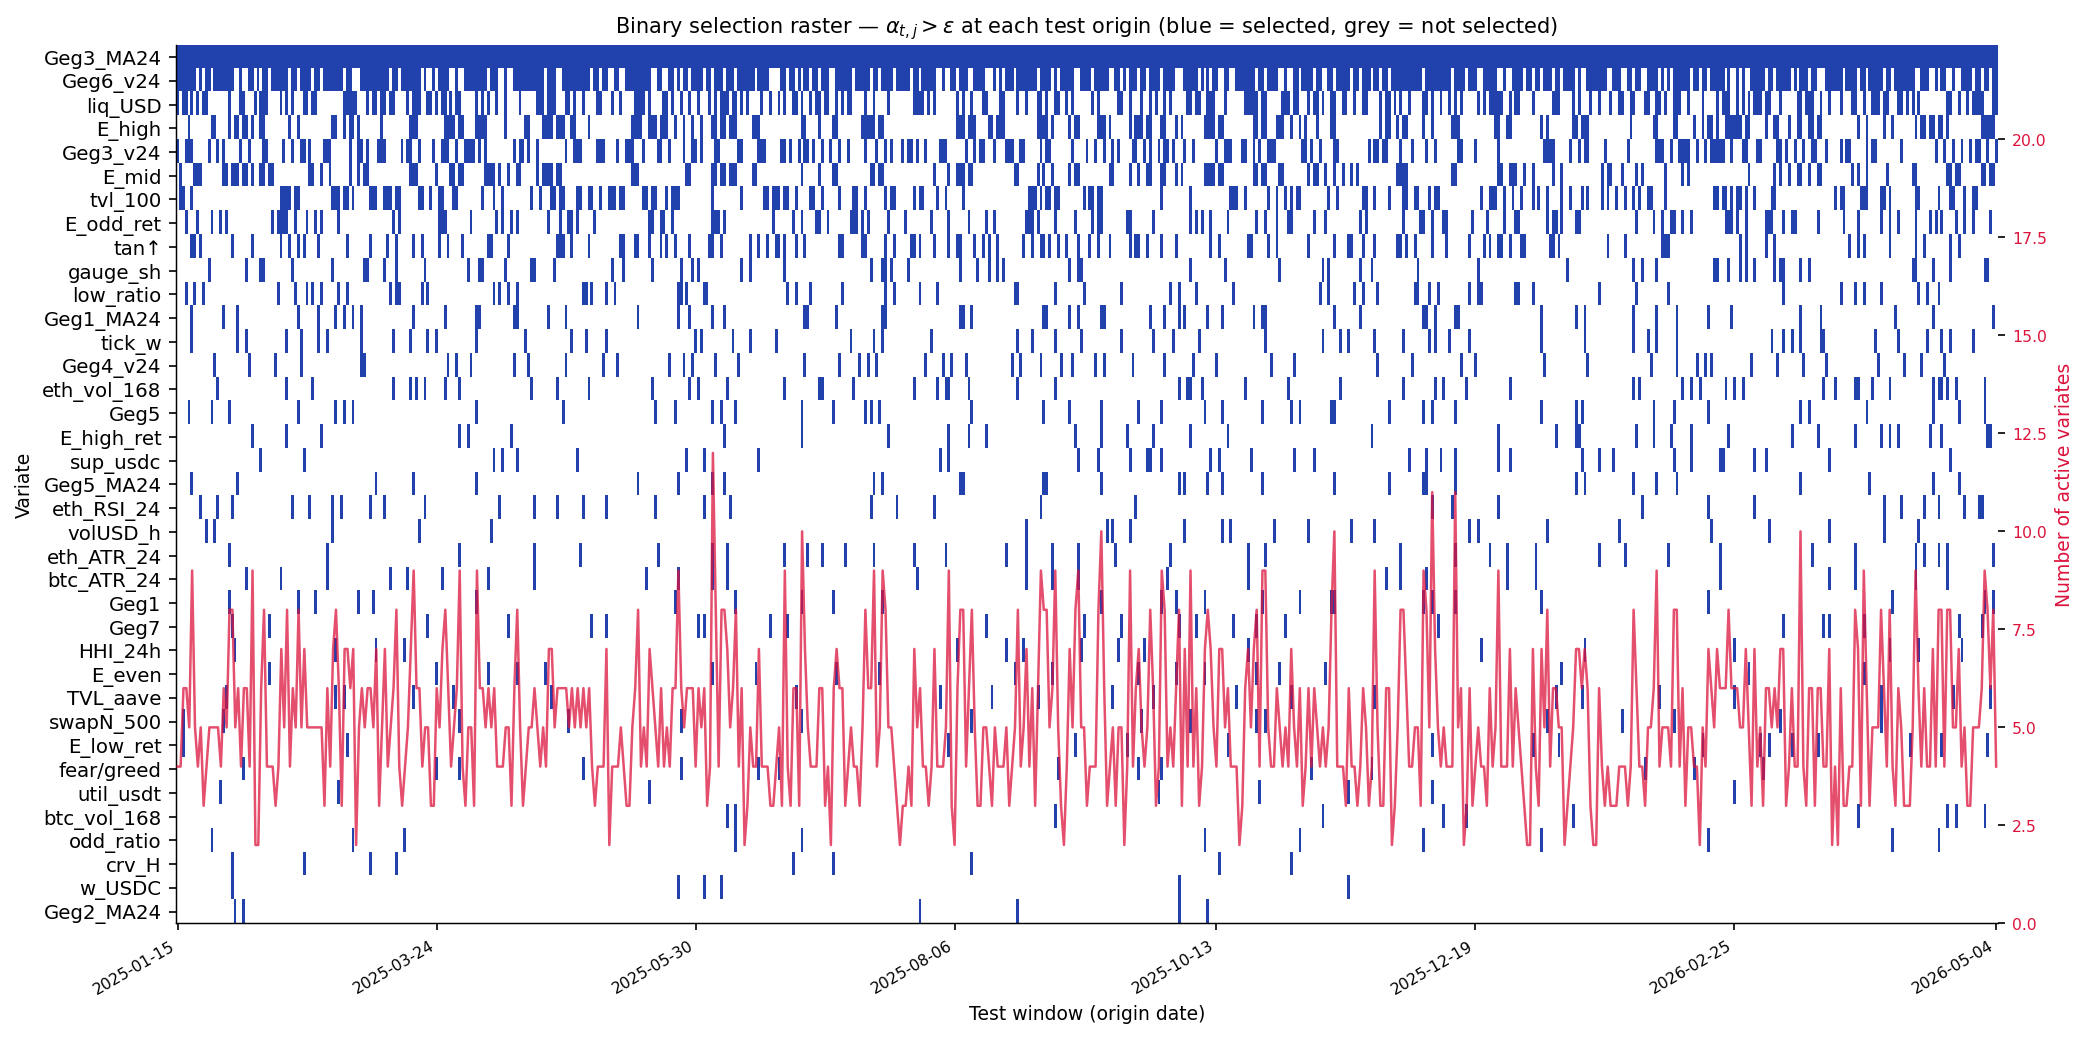

Saved fig3_selection_raster.{pdf,png}


In [47]:
# Binary raster  (T, n_show), sorted by support freq
raster = selected[:, sort_idx][:, :n_show].astype(np.float32)
MAX_ROWS = 600
step     = max(1, T // MAX_ROWS)
raster_ds = raster[::step, :]
dates_ds  = cutoff_dt[::step]
T_ds      = raster_ds.shape[0]
K_ds      = K_t[::step]

fig, ax = plt.subplots(figsize=(14, 7))

ax.imshow(raster_ds.T, aspect='auto', cmap=C_SEL,
          origin='upper', interpolation='nearest', vmin=0, vmax=1)

n_ticks  = 8
tick_pos = np.linspace(0, T_ds - 1, n_ticks, dtype=int)
ax.set_xticks(tick_pos)
ax.set_xticklabels([dates_ds[i].strftime('%Y-%m-%d') for i in tick_pos],
                   rotation=30, ha='right', fontsize=ANNOT_SIZE)
ax.set_xlabel('Test window (origin date)')

ax.set_yticks(np.arange(n_show))
ax.set_yticklabels([short_sorted[i] for i in range(n_show)], fontsize=9.5)
ax.set_ylabel('Variate')
ax.set_title(
    r'Binary selection raster — $\alpha_{t,j}>\varepsilon$ at each test origin '
    r'(blue = selected, grey = not selected)',
    fontsize=TITLE_SIZE, pad=6
)
ax.spines['top'].set_visible(False)

# Overlay K_t count on right axis
ax2 = ax.twinx()
ax2.plot(np.arange(T_ds), K_ds, color=C_WEIGHT, lw=1.2, alpha=0.75, zorder = 4)
ax2.set_ylabel('Number of active variates', color=C_WEIGHT, fontsize=LABEL_SIZE)
ax2.tick_params(axis='y', labelcolor=C_WEIGHT, labelsize=ANNOT_SIZE)
ax2.set_ylim(0, K_t.max() * 1.6)
ax2.spines['top'].set_visible(False)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('fig3_selection_raster.png', dpi=SAVE_DPI, transparent = True)
plt.show()
print('Saved fig3_selection_raster.{pdf,png}')

## Figure 4 — Distribution of active variate count $K_t$

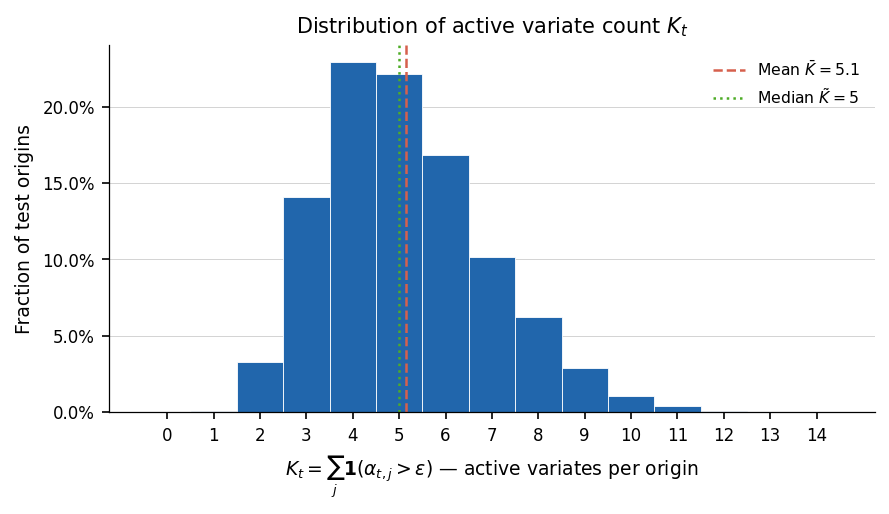

Saved fig4_K_distribution.{pdf,png}


In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.5))

K_max = int(K_t.max())
bins  = np.arange(-0.5, K_max + 1.5)
ax.hist(K_t, bins=bins, color=C_FREQ, edgecolor='white', linewidth=0.4,
        weights=np.ones(T) / T)

ax.axvline(K_t.mean(), ls='--', lw=1.2, color=C_WEIGHT,
           label=f'Mean $\\bar K={K_t.mean():.1f}$')
ax.axvline(np.median(K_t), ls=':', lw=1.2, color=C_COND,
           label=f'Median $\\tilde K={np.median(K_t):.0f}$')

ax.set_xlabel(r'$K_t = \sum_j\mathbf{1}(\alpha_{t,j}>\varepsilon)$ — active variates per origin')
ax.set_ylabel('Fraction of test origins')
ax.set_title('Distribution of active variate count $K_t$', fontsize=TITLE_SIZE)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_xticks(np.arange(0, K_max + 1))
ax.legend()
ax.yaxis.grid(True, lw=0.4, color='#cccccc', zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig4_K_distribution.png', dpi=SAVE_DPI, transparent = True)
plt.show()
print('Saved fig4_K_distribution.{pdf,png}')

## Table — LaTeX export (top 20)

In [11]:
TOP_TABLE = 20
latex_df = stats_df.head(TOP_TABLE)[[
    'variate', 'support_freq', 'mean_weight', 'cond_mean', 'n_selected'
]].copy()
latex_df.columns = [
    'Variate',
    r'$s_j$',
    r'$\bar{\alpha}_j$',
    r'$\bar{\alpha}_j^+$',
    r'$n_{\rm sel}$',
]

latex_str = latex_df.to_latex(
    index=True, index_names=True,
    float_format='{:.4f}'.format,
    escape=False,
    caption=(
        f'Top {TOP_TABLE} variates ranked by support frequency $s_j$ over $T={T:,}$ test origins. '
        r'$\bar{\alpha}_j$ is the unconditional mean sparsemax weight; '
        r'$\bar{\alpha}_j^+$ is the conditional mean given selection ($\alpha_{t,j}>\varepsilon$); '
        r'$n_{\rm sel}$ is the number of origins at which the variate is active.'
    ),
    label='tab:sparse_variates',
)

with open('table_sparse_variates.tex', 'w') as f:
    f.write(latex_str)

print('Saved table_sparse_variates.tex')
print(latex_str)

Saved table_sparse_variates.tex
\begin{table}
\caption{Top 20 variates ranked by support frequency $s_j$ over $T=11,391$ test origins. $\bar{\alpha}_j$ is the unconditional mean sparsemax weight; $\bar{\alpha}_j^+$ is the conditional mean given selection ($\alpha_{t,j}>\varepsilon$); $n_{\rm sel}$ is the number of origins at which the variate is active.}
\label{tab:sparse_variates}
\begin{tabular}{llrrrr}
\toprule
 & Variate & $s_j$ & $\bar{\alpha}_j$ & $\bar{\alpha}_j^+$ & $n_{\rm sel}$ \\
rank &  &  &  &  &  \\
\midrule
1 & Gegenbauer_0.1_deg3_MA24 & 0.9956 & 0.5222 & 0.5245 & 11341 \\
2 & Gegenbauer_0.1_deg6_vol24 & 0.7174 & 0.1780 & 0.2481 & 8172 \\
3 & liquidation_USD & 0.3999 & 0.0387 & 0.0969 & 4555 \\
4 & E_high & 0.3420 & 0.0452 & 0.1321 & 3896 \\
5 & Gegenbauer_0.1_deg3_vol24 & 0.3308 & 0.0376 & 0.1135 & 3768 \\
6 & E_mid & 0.2545 & 0.0273 & 0.1074 & 2899 \\
7 & tvlUSD_100 & 0.2484 & 0.0258 & 0.1038 & 2830 \\
8 & E_odd_logret & 0.2121 & 0.0152 & 0.0715 & 2416 \\
9 & tangent_u

## Figure S1 (Supplementary) — Joint selection × attention heatmap

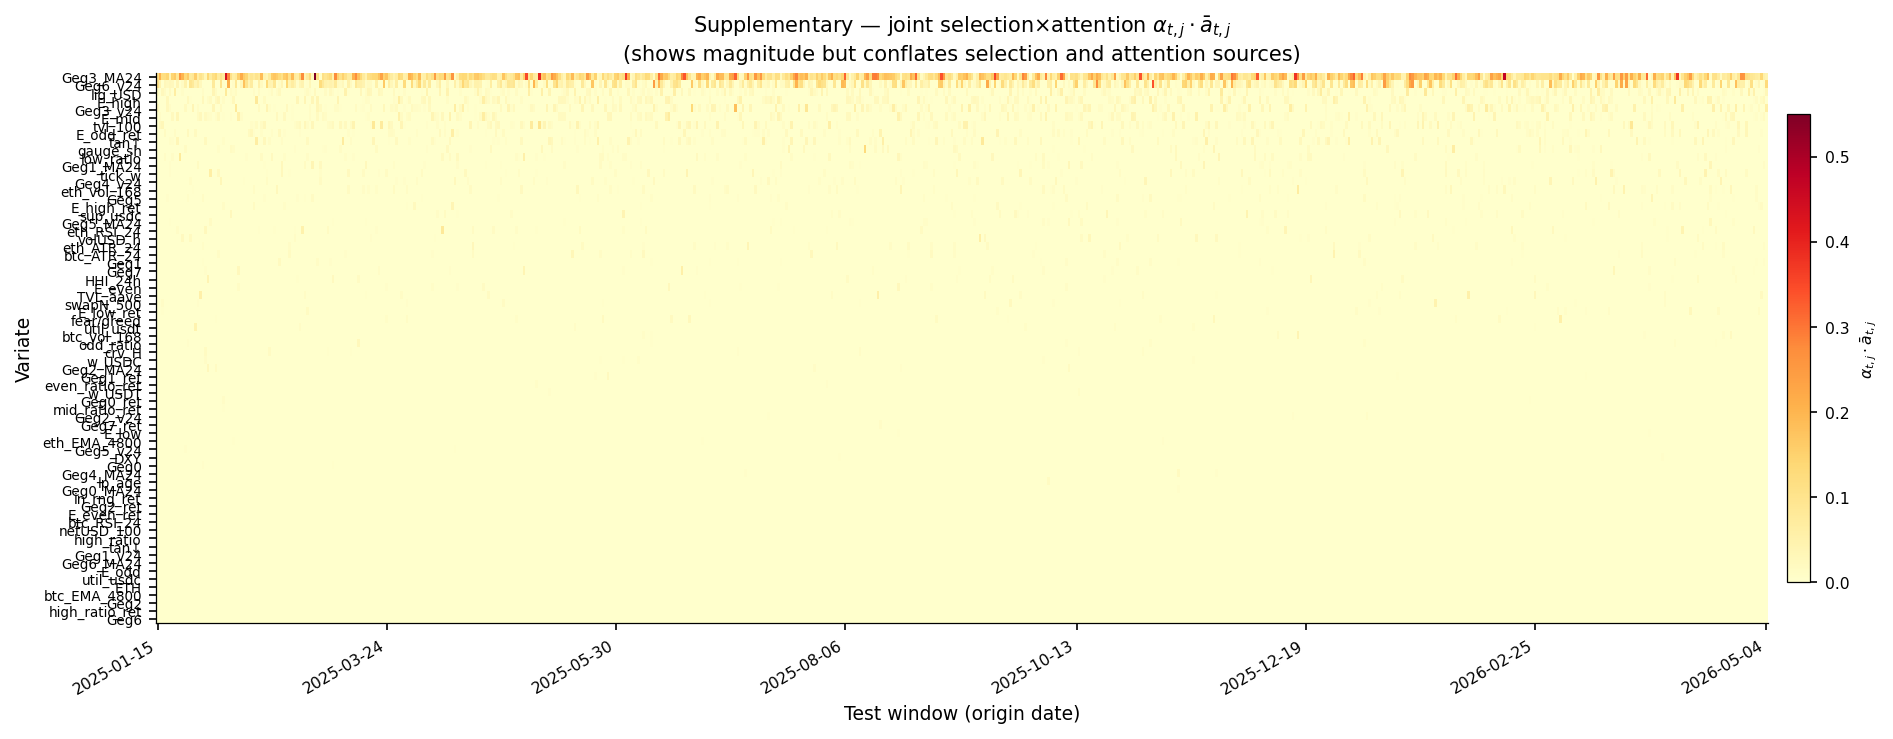

Saved figS1_joint_heatmap.{pdf,png}


In [ ]:
# α_{t,j} * (mean cross-attention over horizons)_{t,j}
cross_mean_h = cross_attn.mean(axis=1)                   # (T, J)
joint        = alpha * cross_mean_h                       # (T, J)
joint_ds     = joint[::step, :][:, sort_idx][:, :n_show]  # (T_ds, n_show)

fig, ax = plt.subplots(figsize=(14, 5))

im = ax.imshow(joint_ds.T, aspect='auto', cmap=C_JOINT,
               origin='upper', interpolation='nearest')

ax.set_xticks(tick_pos)
ax.set_xticklabels([dates_ds[i].strftime('%Y-%m-%d') for i in tick_pos],
                   rotation=30, ha='right', fontsize=ANNOT_SIZE)
ax.set_xlabel('Test window (origin date)')
ax.set_yticks(np.arange(n_show))
ax.set_yticklabels([short_sorted[i] for i in range(n_show)], fontsize=6.5)
ax.set_ylabel('Variate')
ax.set_title(
    r'Supplementary — joint selection$\times$attention $\alpha_{t,j}\cdot\bar a_{t,j}$'
    '\n(shows magnitude but conflates selection and attention sources)',
    fontsize=TITLE_SIZE, pad=6
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.01)
cb.set_label(r'$\alpha_{t,j}\cdot\bar a_{t,j}$', fontsize=ANNOT_SIZE)
cb.ax.tick_params(labelsize=ANNOT_SIZE)

plt.tight_layout()
plt.savefig('figS1_joint_heatmap.png', dpi=SAVE_DPI, transparent = True)
plt.show()
print('Saved figS1_joint_heatmap.{pdf,png}')

## Summary

In [13]:
print('=' * 60)
print('SPARSE VARIATE SELECTION — SUMMARY')
print('=' * 60)
print(f'Test origins T            : {T:,}')
print(f'Total variates J          : {J}')
print(f'Forecast horizons H       : {H}')
print(f'Tolerance ε               : {EPS}')
print()
print(f'Variates ever selected    : {ever_sel}/{J}  ({100*ever_sel/J:.1f}%)')
print(f'Global selection rate     : {selected.mean():.4f}')
print()
print('Active variates K_t per origin — percentiles:')
for p in [0, 25, 50, 75, 90, 95, 99, 100]:
    print(f'  P{p:3d}: {np.percentile(K_t, p):.1f}')
print(f'  Mean: {K_t.mean():.2f}   Std: {K_t.std():.2f}')
print()
print('Top 10 variates by support frequency:')
for r, row in stats_df.head(10).iterrows():
    print(f'  {r:2d}. {row.variate:<40s}  '
          f's={row.support_freq:.4f}  ᾱ={row.mean_weight:.4f}  ᾱ⁺={row.cond_mean:.4f}')

SPARSE VARIATE SELECTION — SUMMARY
Test origins T            : 11,391
Total variates J          : 97
Forecast horizons H       : 24
Tolerance ε               : 1e-08

Variates ever selected    : 68/97  (70.1%)
Global selection rate     : 0.0530

Active variates K_t per origin — percentiles:
  P  0: 1.0
  P 25: 4.0
  P 50: 5.0
  P 75: 6.0
  P 90: 8.0
  P 95: 8.0
  P 99: 10.0
  P100: 14.0
  Mean: 5.15   Std: 1.77

Top 10 variates by support frequency:
   1. Gegenbauer_0.1_deg3_MA24                  s=0.9956  ᾱ=0.5222  ᾱ⁺=0.5245
   2. Gegenbauer_0.1_deg6_vol24                 s=0.7174  ᾱ=0.1780  ᾱ⁺=0.2481
   3. liquidation_USD                           s=0.3999  ᾱ=0.0387  ᾱ⁺=0.0969
   4. E_high                                    s=0.3420  ᾱ=0.0452  ᾱ⁺=0.1321
   5. Gegenbauer_0.1_deg3_vol24                 s=0.3308  ᾱ=0.0376  ᾱ⁺=0.1135
   6. E_mid                                     s=0.2545  ᾱ=0.0273  ᾱ⁺=0.1074
   7. tvlUSD_100                                s=0.2484  ᾱ=0.0258  ᾱ⁺=0.1038
